In [25]:
import pandas as pd

df = pd.read_csv('processed_events.csv')
print(df['shot_type_name'].value_counts())
df['time_on_field'] = pd.to_timedelta(df['time_on_field'], errors='coerce')
print(df[df['time_on_field'] <= pd.Timedelta(0)])
time_on_field_valid = df[df['time_on_field'] <= pd.Timedelta(0)].index
df.drop(time_on_field_valid, inplace=True)
not_open_plays = df[df['shot_type_name'] != 'Open Play'].index
df.drop(not_open_plays, inplace=True)
print(df.info())
print(df['shot_type_name'].value_counts())

C:\Users\yeiso\AppData\Local\Temp\ipykernel_21888\2787721342.py:3: DtypeWarning: Columns (47,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processed_events.csv')


shot_type_name
Open Play    82402
Free Kick     4231
Penalty       1361
Corner          28
Kick Off         1
Name: count, dtype: int64
                                         id  index  period     timestamp  \
7012   1e00f030-41ba-4e02-8f4e-5f0c96bd0ccb   2267       2  00:10:02.892   
7022   5146e2c1-79c3-4728-9727-6568d39631a7   2862       2  00:28:35.315   
27133  db90e5e8-1f08-4588-8e06-4727a97fddd4   3093       2  00:26:15.688   
27137  c20fad17-97f0-4190-aec1-b345f65bd584   4008       3  00:03:39.777   
27138  d8230ce5-7a77-40f2-9b82-94bf62eb9247   4036       3  00:04:25.307   
...                                     ...    ...     ...           ...   
77438  2567327b-53ca-4e38-99ac-f7745a67977b   3185       2  00:45:04.346   
77444  a2bb1cde-fad8-451e-bbcc-a61bcf4e589e   3612       3  00:09:55.079   
86621  0e7fd056-e219-40ab-90b1-fb9adf15bb17   3041       2  00:40:43.480   
86628  36b55ac5-a18c-461d-9bc3-30f2dd513622   3769       4  00:00:36.793   
86993  0f321124-e4d6-4f8b-b1

In [28]:
df = pd.read_csv('processed_events.csv')
df.columns

df.info()

#Drop columns that won't be of any use
#First, drop any columns that don't have any value, or that have the same value for all rows
nunique = df.nunique()
cols_to_drop = nunique[nunique == 0].index
df.drop(cols_to_drop, axis=1, inplace=True)
#print('these are columns',df.columns)
#df.drop(['player_id', 'player_name', 'position_id', 'position_name', 'off_camera', 'shot_end_location', 'shot_outcome_name', 'shot_technique_name', 'shot_type_id', 'shot_type_name'], axis = 1, inplace = True)
#df.drop(['out', 'shot_saved_to_post', 'shot_deflected', 'shot_saved_off_target', 'match_id'], axis = 1, inplace = True)
#df.drop(['duel_type_id', 'duel_type_name', 'counterpress', 'interception_outcome_id', 'interception_outcome_name', 'off_camera', 'ball_recovery_recovery_failure'])
#Decide what to do with event's location -- Decided, we need it for distance and angle calculation, then, it can be dropped. 
#Decide what to do with statsbomb xG
#shot_outcome_id needs to be encoded to have only 1 or 0
#Fill following columns with false when values are emtpy
#fill_false = ['shot_open_goal', 'shot_follows_dribble', 'shot_redirect', 'under_pressure', 'shot_aerial_won', 'shot_one_on_one']
#for col in fill_false:
#    if col in df.columns:
#        df[col] = df[col].fillna(False).astype(bool)
        
df.to_csv("processed_events.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82309 entries, 0 to 82308
Columns: 142 entries, id to winning_team
dtypes: bool(6), float64(112), int64(10), object(14)
memory usage: 85.9+ MB


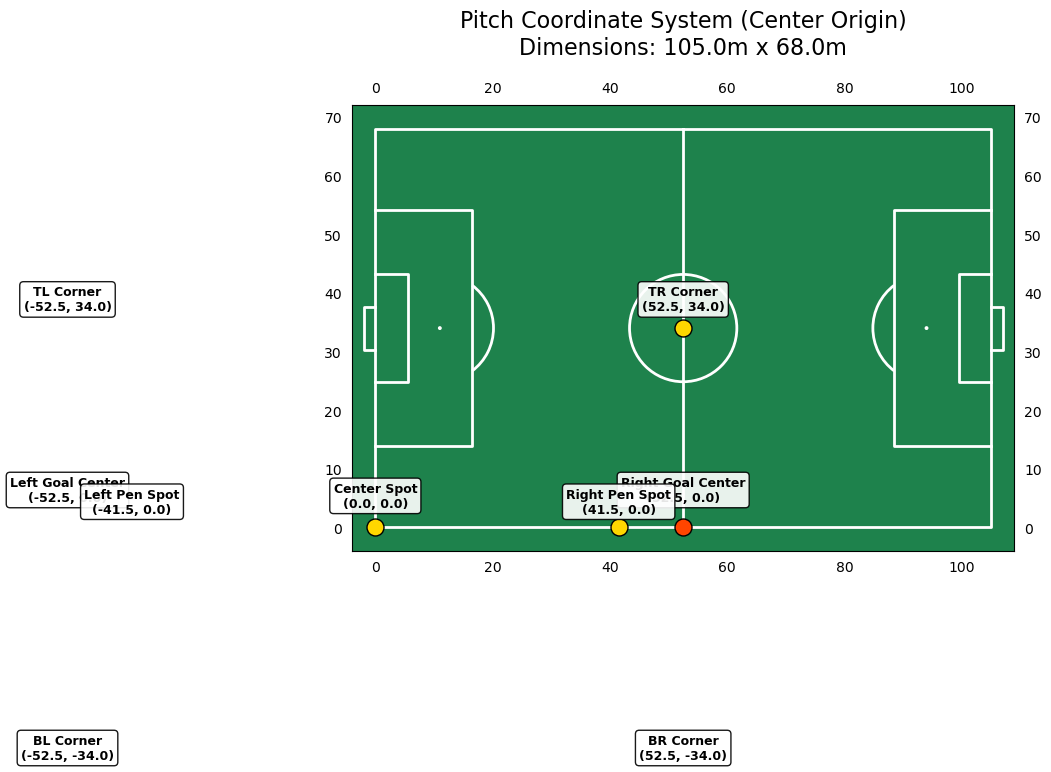

In [10]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

# ==========================================
# 1. Configuration
# ==========================================
# Define standard pitch dimensions in meters
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# Calculate half dimensions for coordinate placement relative to center (0,0)
HALF_LENGTH = PITCH_LENGTH_M / 2.0  # e.g., 52.5m
HALF_WIDTH = PITCH_WIDTH_M / 2.0    # e.g., 34.0m

# Define colors
PITCH_COLOR = '#1e824c' # A nice grass green
LINE_COLOR = 'white'
MARKER_COLOR = '#ffd700' # Gold for general points
GOAL_MARKER_COLOR = '#ff4500' # OrangeRed for goals

# ==========================================
# 2. Helper Function for Annotation
# ==========================================
def annotate_coordinate(ax, x, y, label, marker_color=MARKER_COLOR, y_offset=2.5):
    """
    Adds a marker and a text label box at a specific (x,y) coordinate.
    """
    # Plot the marker dot
    ax.scatter(x, y, s=150, c=marker_color, edgecolors='black', zorder=10)
    
    # Prepare the text label
    coord_text = f"{label}\n({x:.1f}, {y:.1f})"
    
    # Add the text with a bounding box for readability
    ax.text(x, y + y_offset, coord_text, 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.9),
            zorder=11)

# ==========================================
# 3. Pitch Setup and Drawing
# ==========================================
# We use 'custom' pitch type to define our specific meter dimensions.
# By default in mplsoccer custom pitches, the center is (0,0).
pitch = Pitch(pitch_type='custom',
              pitch_length=PITCH_LENGTH_M,
              pitch_width=PITCH_WIDTH_M,
              line_color=LINE_COLOR,
              pitch_color=PITCH_COLOR,
              linewidth=2,
              goal_type='box', # Draws the goal net area clearly
              axis=True, label=True # Useful for debugging coordinates
              )

# Create the figure and axes
fig, ax = pitch.draw(figsize=(14, 9))

# ==========================================
# 4. Annotating Key Coordinates
# ==========================================

# --- The Center ---
annotate_coordinate(ax, 0, 0, "Center Spot", y_offset=3)

# --- The Corners ---
# Top-Left
annotate_coordinate(ax, -HALF_LENGTH, HALF_WIDTH, "TL Corner")
# Top-Right
annotate_coordinate(ax, HALF_LENGTH, HALF_WIDTH, "TR Corner")
# Bottom-Left (using negative y_offset to put text below marker)
annotate_coordinate(ax, -HALF_LENGTH, -HALF_WIDTH, "BL Corner", y_offset=-6)
# Bottom-Right
annotate_coordinate(ax, HALF_LENGTH, -HALF_WIDTH, "BR Corner", y_offset=-6)

# --- The Goals (Center of the goal line) ---
annotate_coordinate(ax, -HALF_LENGTH, 0, "Left Goal Center", 
                   marker_color=GOAL_MARKER_COLOR, y_offset=4)
annotate_coordinate(ax, HALF_LENGTH, 0, "Right Goal Center", 
                   marker_color=GOAL_MARKER_COLOR, y_offset=4)


# --- Optional: Penalty Spots ---
# Standard penalty spot is 11m from goal line
penalty_dist_x = HALF_LENGTH - 11.0
annotate_coordinate(ax, -penalty_dist_x, 0, "Left Pen Spot", y_offset=2)
annotate_coordinate(ax, penalty_dist_x, 0, "Right Pen Spot", y_offset=2)


# Final Figure touches
plt.title(f"Pitch Coordinate System (Center Origin)\nDimensions: {PITCH_LENGTH_M}m x {PITCH_WIDTH_M}m", 
          fontsize=16, color='black', pad=20)

# Ensure nothing is cut off
plt.tight_layout()

# To save the image uncomment the next line:
# plt.savefig('pitch_coordinates.png', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
type(df['location'].iloc[0])

str